29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Kích thước dữ liệu gốc:
X_train: (60000, 28, 28), y_train: (60000,)
X_test: (10000, 28, 28), y_test: (10000,)

Kích thước dữ liệu sau khi phẳng hóa (Reshape):
X_train: (60000, 784)
X_test: (10000, 784)

Số lượng lớp (Classes): 10
Các nhãn lớp: [0 1 2 3 4 5 6 7 8 9]


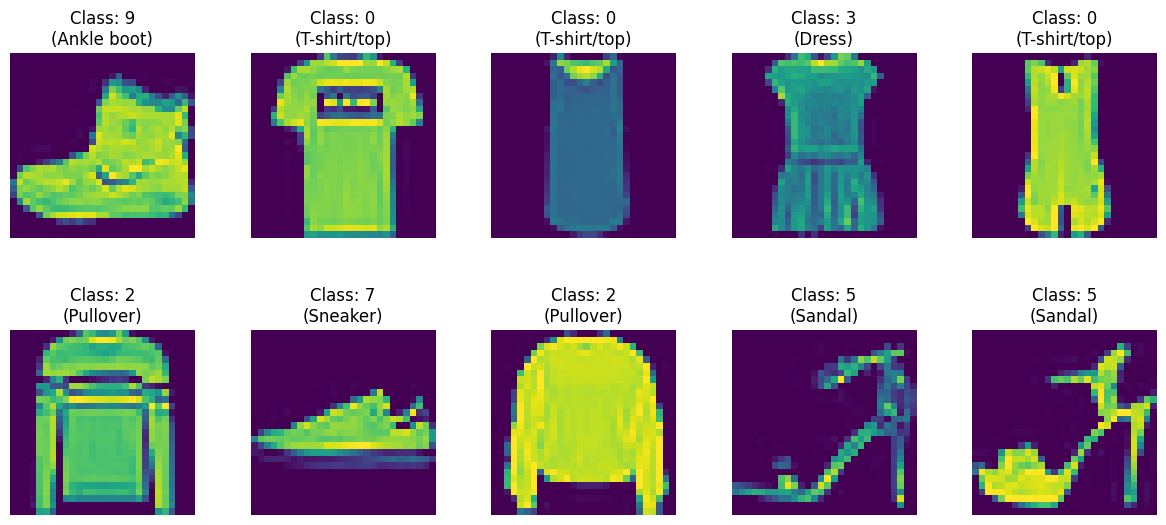

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8212 - loss: 0.5046 - val_accuracy: 0.8565 - val_loss: 0.3914
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8648 - loss: 0.3719 - val_accuracy: 0.8643 - val_loss: 0.3665
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8789 - loss: 0.3315 - val_accuracy: 0.8782 - val_loss: 0.3309
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8893 - loss: 0.3048 - val_accuracy: 0.8767 - val_loss: 0.3220
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8932 - loss: 0.2889 - val_accuracy: 0.8778 - val_loss: 0.3242
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8988 - loss: 0.2732 - val_accuracy: 0.8775 - val_loss: 0.3431
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9020 - loss: 0.2592 - val_accuracy: 0.8770 - val_loss: 0.3481
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9063 - loss: 0.

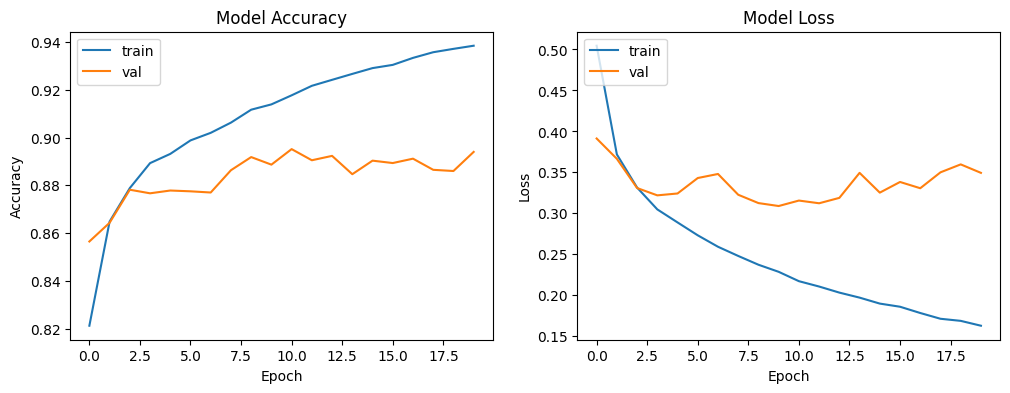

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- Kết quả dự đoán thử nghiệm ---
Ảnh số 0 - Dự đoán: 9 | Thực tế (True label): 9
Ảnh số 10 - Dự đoán: 4 | Thực tế (True label): 4


In [1]:
# ==========================================
# 1. NẠP THƯ VIỆN KHỞI TẠO
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

# ==========================================
# 2. TẢI VÀ ĐỌC TẬP DỮ LIỆU FASHION MNIST
# ==========================================
# Tải bộ dữ liệu tích hợp sẵn trong TensorFlow
fashion = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion.load_data()

print("Kích thước dữ liệu gốc:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}\n")

# Định nghĩa 10 nhãn tương ứng của tập dữ liệu để trực quan hóa
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# ==========================================
# 3. TIỀN XỬ LÝ DỮ LIỆU
# ==========================================
# Reshape dữ liệu từ ma trận ảnh 3D (28x28) thành mảng phẳng 2D (784 features)
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

# Chuẩn hóa dữ liệu về khoảng [0, 1] sử dụng MinMaxScaler
minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train.astype('float32'))
X_test = minmax.transform(X_test.astype('float32'))

print("Kích thước dữ liệu sau khi phẳng hóa (Reshape):")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}\n")
print('Số lượng lớp (Classes):', len(np.unique(y_train)))
print('Các nhãn lớp:', np.unique(y_train))

# ==========================================
# 4. TRỰC QUAN HÓA DỮ LIỆU (Hiển thị 10 hình ảnh đầu tiên)
# ==========================================
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6))
ax = axes.ravel()

for i in range(10):
    # Trả lại hình dạng ảnh 28x28 để hiển thị hình ảnh đồ họa
    ax[i].imshow(X_train[i].reshape(28, 28), cmap='viridis')
    ax[i].set_title(f"Class: {y_train[i]}\n({class_names[y_train[i]]})")
    ax[i].axis('off') # Ẩn các trục tọa độ cho đẹp

plt.subplots_adjust(hspace=0.5)
plt.show()

# ==========================================
# 5. XÂY DỰNG KIẾN TRÚC MÔ HÌNH ANN
# ==========================================
fashion_model = Sequential()

# Thêm tầng Hidden Layer đầu tiên: 256 neuron, hàm kích hoạt ReLU
fashion_model.add(Dense(input_dim=X_train.shape[1], units=256,
                        kernel_initializer='uniform', activation='relu'))

# Thêm tầng Output Layer: 10 neuron (do có 10 lớp), hàm kích hoạt Softmax để tính xác suất
fashion_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

# Biên dịch mô hình (Compile)
fashion_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Xem cấu trúc tổng quan của mạng
fashion_model.summary()

# ==========================================
# 6. HUẤN LUYỆN MÔ HÌNH (Train Model)
# ==========================================
# Trích ra 10% (validation_split=0.1) từ tập train để làm tập kiểm thử (Validation) trong khi học
model_fit = fashion_model.fit(X_train, y_train,
                              validation_split=0.1,
                              epochs=20,
                              batch_size=32,
                              verbose=1)

# ==========================================
# 7. ĐÁNH GIÁ MÔ HÌNH BẰNG ĐỒ THỊ
# ==========================================
# Đồ thị biểu diễn độ chính xác (Accuracy)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'], label='train')
plt.plot(model_fit.history['val_accuracy'], label='val')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Đồ thị biểu diễn độ lỗi (Loss)
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'], label='train')
plt.plot(model_fit.history['val_loss'], label='val')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.show()

# ==========================================
# 8. DỰ BÁO ẢNH MỚI TRÊN TẬP TEST
# ==========================================
predictions = fashion_model.predict(X_test)

print("\n--- Kết quả dự đoán thử nghiệm ---")
print(f"Ảnh số 0 - Dự đoán: {np.argmax(predictions[0])} | Thực tế (True label): {y_test[0]}")
print(f"Ảnh số 10 - Dự đoán: {np.argmax(predictions[10])} | Thực tế (True label): {y_test[10]}")

Đọc file từ drive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
-> Đã kết nối Drive và tìm thấy các file dữ liệu thành công!

--- 5 dòng đầu tiên của tập Train ---
   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      6     104      29      16     112      61      83     111     216   
1      3     189     209     216     224     110     103      59     170   
2      7     220      21     195     147      95     227     241      67   
3      4     175      36     142     162     219     198     159      10   
4      6      49       2     204     106     112      93     253     117   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0      85  ...       199        22        46        89        45       106   
1     203  ...        73       232       223       225        62       155   
2     218  ...       174        48       226       107       225       160   
3 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)


--- Bắt đầu huấn luyện mô hình ---
Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.1022 - loss: 2.3389 - val_accuracy: 0.0800 - val_loss: 2.3488
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1067 - loss: 2.3159 - val_accuracy: 0.1400 - val_loss: 2.2826
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1467 - loss: 2.2503 - val_accuracy: 0.1400 - val_loss: 2.3289
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2378 - loss: 2.2136 - val_accuracy: 0.1400 - val_loss: 2.3240
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1889 - loss: 2.2219 - val_accuracy: 0.1200 - val_loss: 2.3418
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2422 - loss: 2.1618 - val_accuracy: 0.1000 - val_loss: 2.2742
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2533 - loss: 2.0951 - val_accuracy: 0.1200 - val_loss: 2.3520
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3089 - loss: 2.

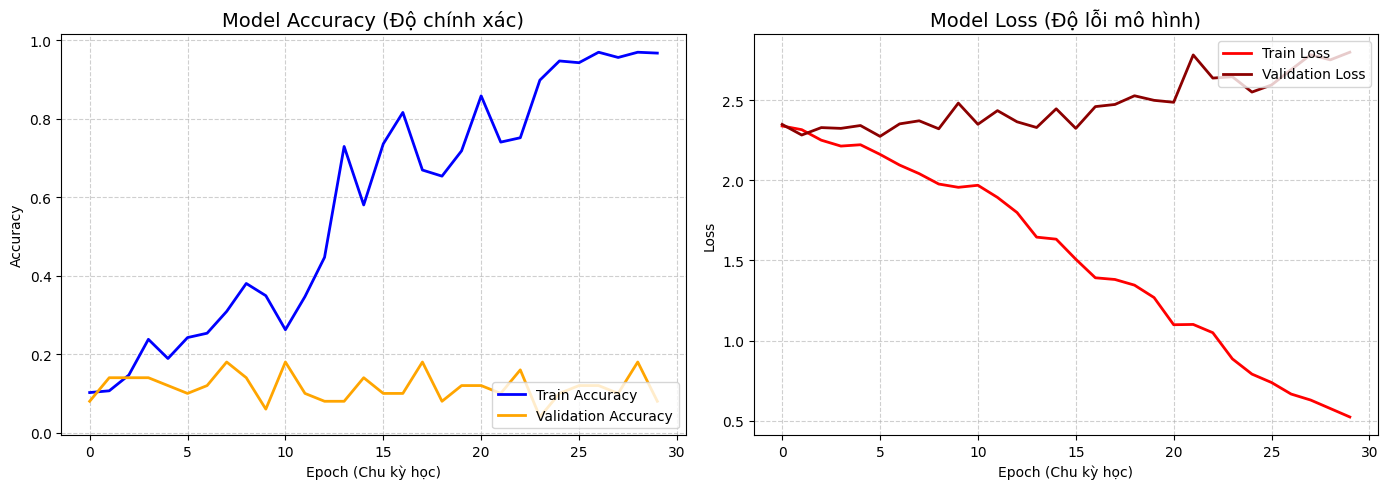


--- Kết quả dự báo thử nghiệm ---
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Giá trị mô hình dự đoán: 6 | Giá trị nhãn thực tế: 5


In [9]:
# =====================================================================
# 1. KẾT NỐI GOOGLE DRIVE VÀ NẠP CÁC THƯ VIỆN
# =====================================================================
from google.colab import drive
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Kết nối tới Google Drive của bạn
drive.mount('/content/drive')

# Cấu hình đường dẫn chính xác tới thư mục chứa file trong Drive của bạn
# 'MyDrive' tương ứng với thư mục "Drive của tôi", theo sau là tên các thư mục con
folder_path = '/content/drive/MyDrive/thDeepLearning/tuan2/'

mnist_train_path = os.path.join(folder_path, 'fashion-mnist_train.csv')
mnist_test_path = os.path.join(folder_path, 'fashion-mnist_test.csv')

# Kiểm tra xem các file có tồn tại hay không trước khi thực hiện đọc dữ liệu
if not os.path.exists(mnist_train_path):
    raise FileNotFoundError(f"Không tìm thấy file Train tại: {mnist_train_path}. Bạn hãy kiểm tra lại tên thư mục và tên file trên Drive nhé!")
if not os.path.exists(mnist_test_path):
    raise FileNotFoundError(f"Không tìm thấy file Test tại: {mnist_test_path}. Bạn hãy kiểm tra lại tên thư mục và tên file trên Drive nhé!")

print("-> Đã kết nối Drive và tìm thấy các file dữ liệu thành công!\n")

# =====================================================================
# 2. ĐỌC TẬP DỮ LIỆU BẰNG THƯ VIỆN PANDAS (MỤC 3.9 TRONG LAB)
# =====================================================================
mnist_train = pd.read_csv(mnist_train_path)
mnist_test = pd.read_csv(mnist_test_path)

print("--- 5 dòng đầu tiên của tập Train ---")
print(mnist_train.head())
print("\nKích thước tập Train gốc từ Drive:", mnist_train.shape)

# =====================================================================
# 3. PHÂN TÁCH ĐẶC TRƯNG (X) VÀ NHÃN (Y)
# =====================================================================
# Cột đầu tiên là 'label' (nhãn lớp), các cột từ chỉ số 1 trở đi là 784 điểm ảnh (features)
X_train = mnist_train.iloc[:, 1:]
X_test = mnist_test.iloc[:, 1:]

y_train = mnist_train.iloc[:, 0]
y_test = mnist_test.iloc[:, 0]

print("\nKích thước ma trận đặc trưng X_train:", X_train.shape)
print('Số lượng phân lớp dữ liệu:', len(np.unique(y_train)))
print('Danh sách các nhãn lớp:', np.unique(y_train))

# =====================================================================
# 4. TIỀN XỬ LÝ DỮ LIỆU (FEATURE SCALING KHÚC NÀY)
# =====================================================================
# Chuyển đổi dữ liệu từ dạng DataFrame sang mảng Numpy float32
X_train = X_train.values.astype('float32')
X_test = X_test.values.astype('float32')

# Áp dụng bộ chuẩn hóa Max-Min (đưa các giá trị điểm ảnh 0-255 về khoảng 0-1)
minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train) # Tìm min, max trên tập Train rồi chuẩn hóa
X_test = minmax.transform(X_test)       # Chuẩn hóa tập Test theo min, max của tập Train

# =====================================================================
# 5. KHỞI TẠO CẤU TRÚC MÔ HÌNH MẠNG NEURAL (ANN)
# =====================================================================
model = Sequential()

# Thêm tầng Ẩn (Hidden Layer): 256 neuron, nhận đầu vào có kích thước 784, hàm kích hoạt relu
model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

# Thêm tầng Đầu ra (Output Layer): 10 neuron đại diện cho 10 lớp phân loại trang phục, hàm softmax
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

# Biên dịch mô hình mạng Neural
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

# =====================================================================
# 6. HUẤN LUYỆN MÔ HÌNH VỚI 30 EPOCHS (LƯU LỊCH SỬ VÀO BIẾN MODEL_FIT)
# =====================================================================
print("\n--- Bắt đầu huấn luyện mô hình ---")
model_fit = model.fit(X_train, y_train,
                        validation_split=0.1, # Trích 10% ra làm tập Validation kiểm định khi học
                        epochs=30,
                        batch_size=32,
                        verbose=1)

# =====================================================================
# 7. KHÚC VẼ ĐỒ THỊ MODEL ACCURACY VÀ MODEL LOSS
# =====================================================================
plt.figure(figsize=(14, 5))

# Đồ thị trái: Model Accuracy
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(model_fit.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy (Độ chính xác)', fontsize=14)
plt.ylabel('Accuracy')
plt.xlabel('Epoch (Chu kỳ học)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Đồ thị phải: Model Loss
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'], label='Train Loss', color='red', linewidth=2)
plt.plot(model_fit.history['val_loss'], label='Validation Loss', color='darkred', linewidth=2)
plt.title('Model Loss (Độ lỗi mô hình)', fontsize=14)
plt.ylabel('Loss')
plt.xlabel('Epoch (Chu kỳ học)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# =====================================================================
# 8. DỰ BÁO NHÃN TRÊN MẪU THỬ NGHIỆM ĐẦU TIÊN
# =====================================================================
print("\n--- Kết quả dự báo thử nghiệm ---")
prediction_0 = np.argmax(model.predict(X_test)[0])
print(f"Giá trị mô hình dự đoán: {prediction_0} | Giá trị nhãn thực tế: {y_test.iloc[0] if hasattr(y_test, 'iloc') else y_test[0]}")

Đọc dữ liệu từ file

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- Bắt đầu quá trình huấn luyện mạng ANN ---
Epoch 1/60


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.2765 - loss: 1.6201 - val_accuracy: 0.5600 - val_loss: 1.4172
Epoch 2/60
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5392 - loss: 1.3811 - val_accuracy: 0.6800 - val_loss: 1.1733
Epoch 3/60
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5668 - loss: 1.2414 - val_accuracy: 0.6800 - val_loss: 1.0208
Epoch 4/60
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5668 - loss: 1.1483 - val_accuracy: 0.6800 - val_loss: 0.9177
Epoch 5/60
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5714 - loss: 1.0993 - val_accuracy: 0.6800 - val_loss: 0.8692
Epoch 6/60
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5991 - loss: 1.0300 - val_accuracy: 0.6800 - val_loss: 0.8430
Epoch 7/60
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6267 - loss: 0.9974 - val_accuracy: 0.6800 - val_loss: 0.8287
Epoch 8/60
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6313 - loss: 0.9659 - val_accuracy: 0.6800 - val_loss: 0.8037
Ep

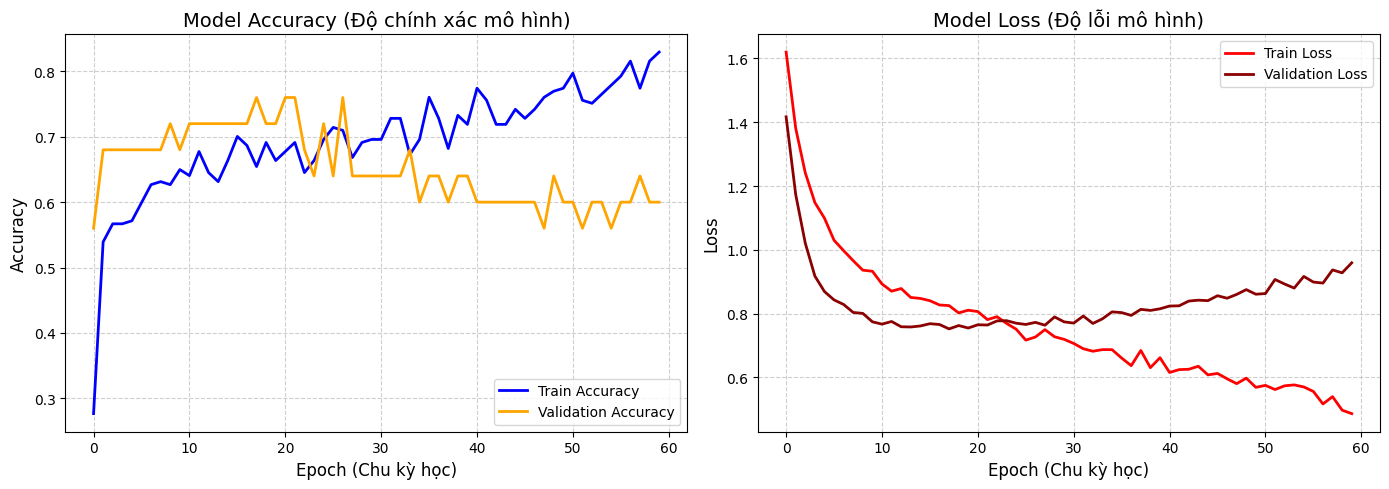


[KẾT QUẢ TỔNG KẾT] Độ chính xác trên tập Test: 55.74%


In [10]:
# =====================================================================
# 1. KẾT NỐI GOOGLE DRIVE VÀ NẠP THƯ VIỆN
# =====================================================================
from google.colab import drive
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt  # Thư viện để vẽ đồ thị

# Kết nối tới Google Drive của bạn
drive.mount('/content/drive')

# Đường dẫn tới file csv trên Google Drive của bạn

mnist_train_path = os.path.join(folder_path, 'fashion-mnist_train.csv')
file_path = '/content/drive/MyDrive/thDeepLearning/tuan2/heart_disease_dataset.csv'

# Kiểm tra file tồn tại
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Không tìm thấy file tại đường dẫn: {file_path}. Hãy kiểm tra lại vị trí lưu file.")

# =====================================================================
# 2. ĐỌC VÀ TIỀN XỬ LÝ DỮ LIỆU CHỮ / SỐ
# =====================================================================
df = pd.read_csv(file_path)

# Bước A: Xử lý giá trị khuyết thiếu (nếu có ô trống thì điền bằng giá trị phổ biến nhất)
for col in df.columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

# Bước B: One-Hot Encoding chuyển đổi dữ liệu chữ (sex, cp, fbs, thal) sang số
df_encoded = pd.get_dummies(df, columns=['sex', 'cp', 'fbs', 'thal'], drop_first=True)

# Bước C: Tách Đặc trưng (X) và Nhãn mục tiêu (y)
X = df_encoded.drop(columns=['state'])
y = df_encoded['state']

# Bước D: Chia tập dữ liệu thành Train (80%) và Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Bước E: Chuẩn hóa dữ liệu về cùng một phân phối bằng StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ... [Khúc đọc file và chuyển chữ thành số One-Hot Encoding ở trên] ...

# Khúc chia dữ liệu thành tập Train (80%) và Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =====================================================================
# KHÚC SỬ DỤNG MAX-MIN SCALER (MINMAXSCALER)
# =====================================================================
from sklearn.preprocessing import MinMaxScaler

# 1. Khởi tạo bộ gom Max-Min
minmax_scaler = MinMaxScaler()

# 2. Vừa học thông số Max, Min vừa biến đổi tập Train
X_train = minmax_scaler.fit_transform(X_train)

# 3. Chỉ biến đổi tập Test theo khung thông số Max, Min của tập Train
X_test = minmax_scaler.transform(X_test)
# =====================================================================


# =====================================================================
# 3. XÂY DỰNG KIẾN TRÚC MẠNG NEURAL (ANN)
# =====================================================================
num_classes = len(np.unique(y))  # Số lượng lớp (mức độ bệnh từ 0 đến 4 -> 5 lớp)

model_heart = Sequential()
model_heart.add(Dense(units=64, input_dim=X_train.shape[1], activation='relu'))
model_heart.add(Dropout(0.2))  # Giảm overfitting
model_heart.add(Dense(units=32, activation='relu'))
model_heart.add(Dense(units=num_classes, activation='softmax'))

model_heart.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

# =====================================================================
# 4. TIẾN HÀNH HUẤN LUYỆN MÔ HÌNH (Lưu lịch sử vào biến `model_fit`)
# =====================================================================
print("\n--- Bắt đầu quá trình huấn luyện mạng ANN ---")
# Trích ra 10% dữ liệu từ tập Train để làm tập kiểm định (Validation) trong khi học
model_fit = model_heart.fit(X_train, y_train,
                              validation_split=0.1,
                              epochs=60,
                              batch_size=16,
                              verbose=1)

# =====================================================================
# 5. VẼ ĐỒ THỊ ĐỘ CHÍNH XÁC (ACCURACY) VÀ ĐỘ LỖI (LOSS)
# =====================================================================
plt.figure(figsize=(14, 5))

# Đồ thị 1: Biển diễn Độ chính xác (Model Accuracy)
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(model_fit.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy (Độ chính xác mô hình)', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Epoch (Chu kỳ học)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Đồ thị 2: Biểu diễn Độ lỗi (Model Loss)
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'], label='Train Loss', color='red', linewidth=2)
plt.plot(model_fit.history['val_loss'], label='Validation Loss', color='darkred', linewidth=2)
plt.title('Model Loss (Độ lỗi mô hình)', fontsize=14)
plt.ylabel('Loss', fontsize=12)
plt.xlabel('Epoch (Chu kỳ học)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# Hiển thị đồ thị lên màn hình Colab
plt.tight_layout()
plt.show()

# =====================================================================
# 6. ĐÁNH GIÁ TRÊN TẬP DỮ LIỆU TEST ĐỘC LẬP
# =====================================================================
test_loss, test_acc = model_heart.evaluate(X_test, y_test, verbose=0)
print(f"\n[KẾT QUẢ TỔNG KẾT] Độ chính xác trên tập Test: {test_acc*100:.2f}%")

Lấy ảnh và so sánh với kho huấn luyện đề xác định hình ảnh là gì

Đang nạp bộ dữ liệu đầy đủ (70.000 ảnh) từ Keras Datasets...
-> Số lượng ảnh tập Train: 60000 ảnh (Kích thước: 28x28)
-> Số lượng ảnh tập Test: 10000 ảnh

[HIỂN THỊ] Hình ảnh trích xuất từ bộ dữ liệu mang nhãn: Ankle boot


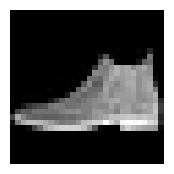

-> Đã tạo xong file ảnh thực tế lưu tại: /content/sample_data/fashion_heavy_image.jpg



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)


--- Bắt đầu huấn luyện mô hình ANN với dải dữ liệu lớn ---
Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8141 - loss: 0.5365 - val_accuracy: 0.8528 - val_loss: 0.4118
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8607 - loss: 0.3898 - val_accuracy: 0.8700 - val_loss: 0.3658
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8765 - loss: 0.3458 - val_accuracy: 0.8673 - val_loss: 0.3557
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8858 - loss: 0.3163 - val_accuracy: 0.8750 - val_loss: 0.3456
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8907 - loss: 0.2987 - val_accuracy: 0.8823 - val_loss: 0.3250
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8968 - loss: 0.2828 - val_accuracy: 0.8825 - val_loss: 0.3210
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9027 - loss: 0.2664 - val_accuracy: 0.8752 - val_loss: 0.3548
Epoch 8/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 

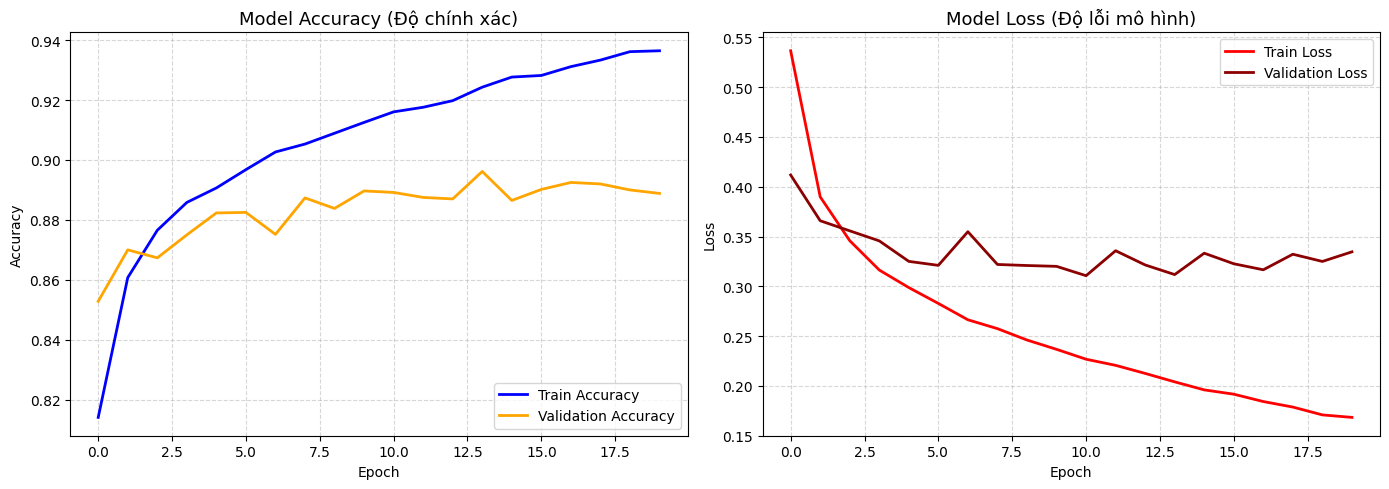


--- BẮT ĐẦU TIỀN XỬ LÝ VÀ DỰ ĐOÁN FILE ẢNH ĐƠN LẺ BẰNG KERAS IMAGE ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step

Mảng tỷ lệ phần trăm xác suất dự đoán của 10 lớp:
 [[1.1845563e-08 8.0241411e-11 7.7011236e-15 2.9483008e-13 3.5423608e-11
  2.4848720e-07 3.9211723e-10 7.6214805e-05 6.2428090e-11 9.9992347e-01]]

[KẾT QUẢ TỔNG HỢP SAU KHI DỰ ĐOÁN]:
-> Tên nhãn thực tế của bức ảnh trích xuất: 9 (Ankle boot)
-> Tên nhãn mô hình ANN sử dụng Keras Image dự đoán: 9 (Ankle boot)


In [17]:
# =====================================================================
# BƯỚC 1: NẠP TOÀN BỘ 70.000 ẢNH TỪ KERAS VÀ XUẤT ẢNH THỰC TẾ
# =====================================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Tạo thư mục sample_data trên bộ nhớ tạm của Colab
os.makedirs('/content/sample_data', exist_ok=True)

print("Đang nạp bộ dữ liệu đầy đủ (70.000 ảnh) từ Keras Datasets...")
# Tải bộ dữ liệu Fashion MNIST chính thức với số lượng ảnh tối đa
(X_train_raw, y_train), (X_test_raw, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print(f"-> Số lượng ảnh tập Train: {X_train_raw.shape[0]} ảnh (Kích thước: {X_train_raw.shape[1]}x{X_train_raw.shape[2]})")
print(f"-> Số lượng ảnh tập Test: {X_test_raw.shape[0]} ảnh")

# Định nghĩa danh sách tên 10 lớp trang phục thời trang
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Lấy ngẫu nhiên bức ảnh đầu tiên từ tập Test để lưu thành file ảnh vật lý kiểm thử
sample_matrix = X_test_raw[0]
actual_label = y_test[0]

# Hiển thị trực quan bức ảnh mẫu này lên màn hình Colab
print(f"\n[HIỂN THỊ] Hình ảnh trích xuất từ bộ dữ liệu mang nhãn: {class_names[actual_label]}")
plt.figure(figsize=(2, 2))
plt.imshow(sample_matrix, cmap='gray')
plt.axis('off')
plt.show()

# Lưu ma trận ảnh này thành một file ảnh vật lý thực sự tên là 'fashion_heavy_image.jpg'
test_image_path = '/content/sample_data/fashion_heavy_image.jpg'
plt.imsave(test_image_path, sample_matrix, cmap='gray')
print(f"-> Đã tạo xong file ảnh thực tế lưu tại: {test_image_path}\n")


# =====================================================================
# BƯỚC 2: TIỀN XỬ LÝ CHUẨN HÓA DỮ LIỆU (DUỠI PHẲNG VECTOR & MAX-MIN SCALER)
# =====================================================================
# Vì ảnh gốc là ma trận 2D (28x28), ta cần duỗi phẳng (flatten) thành dạng hàng dọc 1D (784,)
# để tương thích với cấu trúc các tầng Dense Layer của mạng ANN (Mục 3.9)
X_train = X_train_raw.reshape(X_train_raw.shape[0], 784).astype('float32')
X_test = X_test_raw.reshape(X_test_raw.shape[0], 784).astype('float32')

# Áp dụng bộ MinMaxScaler đưa giá trị pixel từ dải [0-255] về khoảng [0-1]
from sklearn.preprocessing import MinMaxScaler
minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)


# =====================================================================
# BƯỚC 3: XÂY DỰNG KIẾN TRÚC VÀ HUẤN LUYỆN MẠNG NEURAL (ANN) (MỤC 3.9)
# =====================================================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

# Tầng Ẩn (Hidden Layer): 256 neuron kết nối đầy đủ, dùng hàm kích hoạt relu
model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

# Tầng Đầu ra (Output Layer): 10 lớp phân loại tương ứng với 10 loại trang phục, hàm softmax
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

# Biên dịch cấu trúc mô hình mạng
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

print("\n--- Bắt đầu huấn luyện mô hình ANN với dải dữ liệu lớn ---")
# Huấn luyện mô hình và lưu tiến trình vào biến model_fit để vẽ đồ thị
model_fit = model.fit(X_train, y_train, validation_split=0.1, epochs=20, batch_size=64, verbose=1)


# =====================================================================
# BƯỚC 4: VẼ ĐỒ THỊ HIỆU NĂNG MODEL ACCURACY VÀ MODEL LOSS
# =====================================================================
plt.figure(figsize=(14, 5))

# Đồ thị hiển thị Model Accuracy qua từng chu kỳ Epoch
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(model_fit.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy (Độ chính xác)', fontsize=13)
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

# Đồ thị hiển thị Model Loss qua từng chu kỳ Epoch
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'], label='Train Loss', color='red', linewidth=2)
plt.plot(model_fit.history['val_loss'], label='Validation Loss', color='darkred', linewidth=2)
plt.title('Model Loss (Độ lỗi mô hình)', fontsize=13)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# =====================================================================
# BƯỚC 5: ĐOẠN ĐỌC FILE ẢNH VÀ TIỀN XỬ LÝ DỰ ĐOÁN (TF.KERAS.PREPROCESSING.IMAGE)
# =====================================================================
print("\n--- BẮT ĐẦU TIỀN XỬ LÝ VÀ DỰ ĐOÁN FILE ẢNH ĐƠN LẺ BẰNG KERAS IMAGE ---")

# 1. Định nghĩa kích thước ảnh cần mẫu về dải vuông 28x28
img_size = (28, 28)

# 2. Tải ảnh từ đường dẫn cụ thể (Đọc file ảnh thực tế đã được xuất ra ở Bước 1)
img = tf.keras.preprocessing.image.load_img(
    test_image_path,
    color_mode="grayscale",
    target_size=img_size
)

# 3. Chuyển đổi đối tượng ảnh thành một mảng dữ liệu Numpy Array
img_array = tf.keras.preprocessing.image.img_to_array(img)

# 4. Chuẩn hóa giá trị điểm ảnh (Feature Scaling) về khoảng [0, 1] giống tập Train
img_array = img_array / 255.0

# 5. Duỗi mảng (Reshape) từ ma trận ảnh 2D thành Vector phẳng 1D (784,) để khớp với tầng đầu vào
img_flat = np.reshape(img_array, (784,))

# 6. Thêm chiều Batch (Batch dimension) thành (1, 784) phù hợp yêu cầu đầu vào của Keras khi predict
img_batch = tf.expand_dims(img_flat, axis=0)

# 7. Đưa vào mô hình mạng ANN đã được huấn luyện xong ở trên để dự báo xác suất
img_prediction = model.predict(img_batch)
print("\nMảng tỷ lệ phần trăm xác suất dự đoán của 10 lớp:\n", img_prediction)

# 8. Lấy chỉ số có giá trị xác suất cao nhất (argmax) để xuất ra kết quả phân loại cuối cùng
score = np.argmax(img_prediction)
print(f"\n[KẾT QUẢ TỔNG HỢP SAU KHI DỰ ĐOÁN]:")
print(f"-> Tên nhãn thực tế của bức ảnh trích xuất: {actual_label} ({class_names[actual_label]})")
print(f"-> Tên nhãn mô hình ANN sử dụng Keras Image dự đoán: {score} ({class_names[score]})")

Bài tập 1

Đang tải bộ dữ liệu ảnh màu CIFAR10 trực tiếp từ Keras Datasets...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
-> Số lượng ảnh tập Train: 50000 ảnh (Kích thước: 32x32x3 - Ảnh màu)
-> Số lượng ảnh tập Test: 10000 ảnh

[HIỂN THỊ] Hình ảnh mẫu trích xuất từ dữ liệu mang nhãn: Cat


/tmp/ipykernel_4701/3366687055.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actual_label = int(y_test[0])


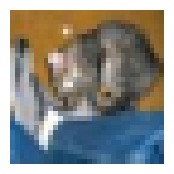

-> Đã tạo xong file ảnh thực tế tại: /content/sample_data/cifar10_test_image.jpg



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 789,258 (3.01 MB)

 Trainable params: 789,258 (3.01 MB)

 Non-trainable params: 0 (0.00 B)


--- Bắt đầu huấn luyện mô hình ANN trên bộ ảnh màu CIFAR10 ---
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3311 - loss: 1.8624 - val_accuracy: 0.3570 - val_loss: 1.7958
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3929 - loss: 1.7040 - val_accuracy: 0.4038 - val_loss: 1.6770
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.4172 - loss: 1.6340 - val_accuracy: 0.4134 - val_loss: 1.6470
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.4351 - loss: 1.5879 - val_accuracy: 0.4290 - val_loss: 1.6260
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.4463 - loss: 1.5583 - val_accuracy: 0.4536 - val_loss: 1.5461
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.4536 - loss: 1.5294 - val_accuracy: 0.4556 - val_loss: 1.5357
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.4659 - loss: 1.4995 - val_accuracy: 0.4456 - val_loss: 1.5656
Epoch 8/20
704/704 ━━━━━━━

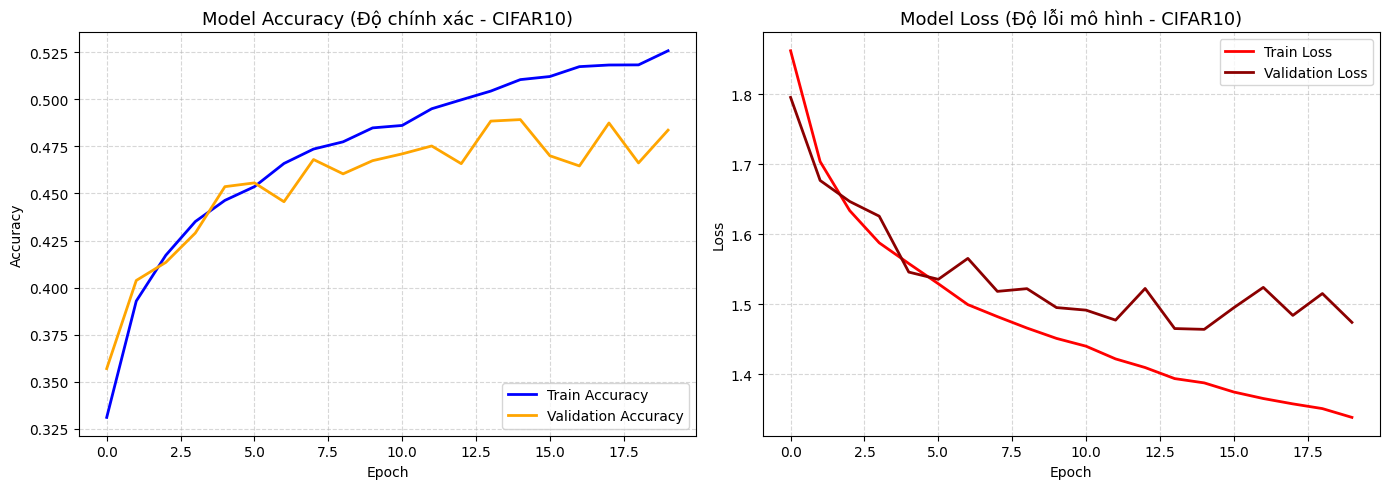


--- BẮT ĐẦU QUÁ TRÌNH TIỀN XỬ LÝ VÀ DỰ ĐOÁN FILE ẢNH ĐƠN LẺ ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step

Mảng tỷ lệ phần trăm xác suất dự đoán của 10 lớp vật thể:
 [[0.05657527 0.0142306  0.18723655 0.30139065 0.05175833 0.30957296
  0.03342755 0.00077015 0.04466627 0.00037171]]

[KẾT QUẢ ĐỐI CHIẾU]:
-> Tên nhãn thực tế của bức ảnh: 3 (Cat)
-> Tên nhãn mô hình ANN dùng Keras Image dự đoán: 5 (Dog)


In [18]:
# =====================================================================
# BƯỚC 1: NẠP BỘ DỮ LIỆU 60.000 ẢNH MÀU CIFAR10 TỪ TENSORFLOW
# =====================================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Tạo thư mục chứa ảnh mẫu trên Colab
os.makedirs('/content/sample_data', exist_ok=True)

print("Đang tải bộ dữ liệu ảnh màu CIFAR10 trực tiếp từ Keras Datasets...")
# Tải bộ dữ liệu CIFAR10 chính thức (Gồm 50.000 ảnh Train, 10.000 ảnh Test)
(X_train_raw, y_train), (X_test_raw, y_test) = tf.keras.datasets.cifar10.load_data()

print(f"-> Số lượng ảnh tập Train: {X_train_raw.shape[0]} ảnh (Kích thước: {X_train_raw.shape[1]}x{X_train_raw.shape[2]}x{X_train_raw.shape[3]} - Ảnh màu)")
print(f"-> Số lượng ảnh tập Test: {X_test_raw.shape[0]} ảnh")

# Định nghĩa danh sách tên 10 lớp đối tượng của bộ dữ liệu CIFAR10 theo đúng chuẩn
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# Lấy một bức ảnh ngẫu nhiên (ảnh đầu tiên index 0) từ tập Test để xuất thành file ảnh vật lý
sample_matrix = X_test_raw[0]
actual_label = int(y_test[0])

# Hiển thị trực quan bức ảnh màu này lên màn hình Colab
print(f"\n[HIỂN THỊ] Hình ảnh mẫu trích xuất từ dữ liệu mang nhãn: {class_names[actual_label]}")
plt.figure(figsize=(2, 2))
plt.imshow(sample_matrix) # Hiển thị ảnh màu không cần cmap='gray'
plt.axis('off')
plt.show()

# Lưu ma trận ảnh màu này thành một file ảnh thực tế mang tên 'cifar10_test_image.jpg'
test_image_path = '/content/sample_data/cifar10_test_image.jpg'
plt.imsave(test_image_path, sample_matrix)
print(f"-> Đã tạo xong file ảnh thực tế tại: {test_image_path}\n")


# =====================================================================
# BƯỚC 2: TIỀN XỬ LÝ CHUẨN HÓA (DUỠI PHẲNG ẢNH MÀU VÀ MAX-MIN SCALER)
# =====================================================================
# Vì ảnh CIFAR10 là ảnh màu 3D (28x28x3 = 3072 điểm ảnh), ta phải duỗi phẳng (Flatten)
# thành vector 1D có kích thước 3072 để đưa vào các tầng Dense Layer của mạng ANN
X_train = X_train_raw.reshape(X_train_raw.shape[0], 3072).astype('float32')
X_test = X_test_raw.reshape(X_test_raw.shape[0], 3072).astype('float32')

# Chuyển đổi mảng nhãn y về dạng vector 1D để tránh lỗi kích thước hình dạng mạng
y_train = y_train.flatten()
y_test = y_test.flatten()

# Áp dụng bộ MinMaxScaler đưa giá trị pixel từ dải [0-255] về khoảng số thực [0-1]
from sklearn.preprocessing import MinMaxScaler
minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)


# =====================================================================
# BƯỚC 3: XÂY DỰNG KIẾN TRÚC VÀ HUẤN LUYỆN MẠNG NEURAL (ANN)
# =====================================================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

# Tầng Ẩn (Hidden Layer): Đầu vào input_dim lúc này là 3072, thiết lập 256 neuron, hàm relu
model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

# Tầng Đầu ra (Output Layer): 10 lớp phân loại đa lớp tương ứng với 10 loại vật thể, hàm softmax
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

# Biên dịch mô hình mạng ANN
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

print("\n--- Bắt đầu huấn luyện mô hình ANN trên bộ ảnh màu CIFAR10 ---")
# Huấn luyện mô hình và lưu tiến trình vào biến model_fit để vẽ đồ thị hiệu năng
model_fit = model.fit(X_train, y_train, validation_split=0.1, epochs=20, batch_size=64, verbose=1)


# =====================================================================
# BƯỚC 4: KHÚC VẼ ĐỒ THỊ MODEL ACCURACY VÀ MODEL LOSS
# =====================================================================
plt.figure(figsize=(14, 5))

# Đồ thị hiển thị Model Accuracy
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(model_fit.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy (Độ chính xác - CIFAR10)', fontsize=13)
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

# Đồ thị hiển thị Model Loss
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'], label='Train Loss', color='red', linewidth=2)
plt.plot(model_fit.history['val_loss'], label='Validation Loss', color='darkred', linewidth=2)
plt.title('Model Loss (Độ lỗi mô hình - CIFAR10)', fontsize=13)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# =====================================================================
# BƯỚC 5: ĐOẠN ĐỌC FILE ẢNH VÀ TIỀN XỬ LÝ DỰ ĐOÁN (TF.KERAS.PREPROCESSING.IMAGE)
# =====================================================================
print("\n--- BẮT ĐẦU QUÁ TRÌNH TIỀN XỬ LÝ VÀ DỰ ĐOÁN FILE ẢNH ĐƠN LẺ ---")

# 1. Định nghĩa kích thước ảnh màu cần mẫu về dải vuông 32x32 của CIFAR10
img_size = (32, 32)

# 2. Tải ảnh màu từ đường dẫn cụ thể (Đọc file ảnh .jpg đã được xuất ra ở Bước 1)
img = tf.keras.preprocessing.image.load_img(
    test_image_path,
    color_mode="rgb",  # CHÚ Ý: Đổi thành "rgb" vì dữ liệu bài tập này là ảnh màu, không dùng "grayscale" nữa
    target_size=img_size
)

# 3. Chuyển đổi đối tượng ảnh (PIL image) thành một mảng dữ liệu Numpy Array
img_array = tf.keras.preprocessing.image.img_to_array(img)

# 4. Chuẩn hóa giá trị điểm ảnh (Feature Scaling) về khoảng [0, 1] giống tập Train
img_array = img_array / 255.0

# 5. Duỗi mảng (Reshape) từ ma trận ảnh màu 3D thành Vector phẳng 1D (3072,) để khớp với tầng đầu vào
img_flat = np.reshape(img_array, (3072,))

# 6. Thêm chiều Batch (Batch dimension) thành (1, 3072) phù hợp yêu cầu hàm dự báo của Keras
img_batch = tf.expand_dims(img_flat, axis=0)

# 7. Đưa vào mô hình mạng ANN đã được huấn luyện xong ở trên để dự báo xác suất
img_prediction = model.predict(img_batch)
print("\nMảng tỷ lệ phần trăm xác suất dự đoán của 10 lớp vật thể:\n", img_prediction)

# 8. Lấy chỉ số có giá trị xác suất cao nhất (argmax) để xuất ra kết quả phân loại cuối cùng
score = np.argmax(img_prediction)
print(f"\n[KẾT QUẢ ĐỐI CHIẾU]:")
print(f"-> Tên nhãn thực tế của bức ảnh: {actual_label} ({class_names[actual_label]})")
print(f"-> Tên nhãn mô hình ANN dùng Keras Image dự đoán: {score} ({class_names[score]})")